# Stance Detection: Opini Publik Indonesia Terhadap Kasus Kekerasan Seksual
**Dataset:** finalDataUNY.csv  
**Models:** NB + TF-IDF | SVM + TF-IDF | SVM + TF-IDF + Emotion | SVM + TF-IDF + VictimBlaming  
**Target:** stance (Neutral, Advocacy, Supportive, VictimBlaming)

## 1. SETUP  & PREPARATION DATA

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install PySastrawi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 6.5 MB/s eta 0:00:00


In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from scipy.sparse import hstack

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    balanced_accuracy_score, cohen_kappa_score,
    confusion_matrix, ConfusionMatrixDisplay
)

print('Set Up Selesai')
np.random.seed(42)

Set Up Selesai


## 2. LOAD DATA

In [4]:
path = "/content/drive/MyDrive/Gemastik/DataFinal/finalDataUNY.csv"
data = pd.read_csv(path)
print('jumlah Baris dan Kolom pada data: ', data.shape)
data.head()

jumlah Baris dan Kolom pada data:  (1500, 2)


,text,stance
0,udh bener di UGM aja lah,Neutral
1,jurusan hukum ❎\npraktek hukum ✅,Neutral
2,"Ini masalah rusaknya moral, bukan hal yang sep...",Advocacy
3,DO aja semuanya,Advocacy
4,Usut tuntas proses hukum dan pecat mahasiswa b...,Advocacy


## 3. EDA (EXPLORATORY DATA ANALYSIS)

In [5]:
print('Info Dataset:')
data.info()
print()
print('Missing Values:')
print(data.isnull().sum())
print()
print('Duplicates Values:')
print(data.duplicated().sum())
print()
print('Distribusi Opini Publik:')
print(data['stance'].value_counts())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1500 non-null   object
 1   stance  1500 non-null   object
dtypes: object(2)
memory usage: 23.6+ KB

Missing Values:
text      0
stance    0
dtype: int64

Duplicates Values:
0

Distribusi Opini Publik:
stance
Neutral          1108
Advocacy          210
Supportive        129
VictimBlaming      53
Name: count, dtype: int64


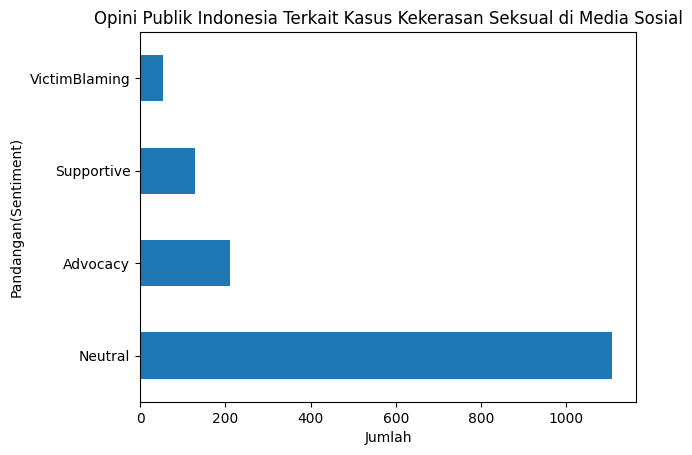

Jumlah Opini Publik Terhadap Kasus Kekerasan Seksual di Media Sosial stance
Neutral          1108
Advocacy          210
Supportive        129
VictimBlaming      53
Name: count, dtype: int64


In [6]:
hitungText = data['stance'].value_counts()

plt.figure()
hitungText.plot(kind = 'barh')
plt.title("Opini Publik Indonesia Terkait Kasus Kekerasan Seksual di Media Sosial")
plt.xlabel("Jumlah")
plt.ylabel("Pandangan(Sentiment)")
plt.show()

print("Jumlah Opini Publik Terhadap Kasus Kekerasan Seksual di Media Sosial",
      hitungText)

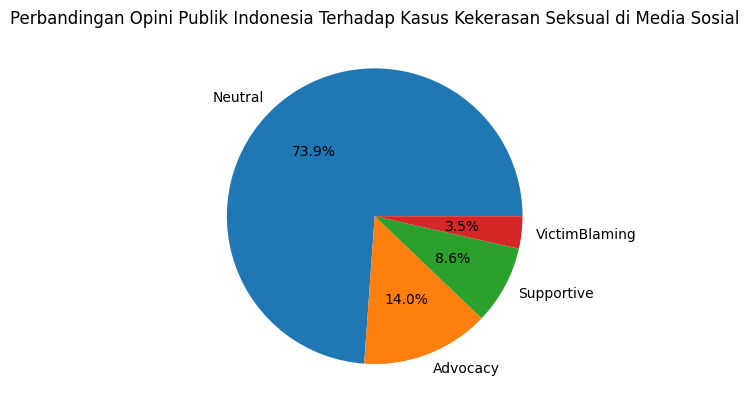

In [7]:
plt.figure()
hitungText.plot(kind='pie', autopct = '%1.1f%%')
plt.title("Perbandingan Opini Publik Indonesia Terhadap Kasus Kekerasan Seksual di Media Sosial")
plt.ylabel('')
plt.show()

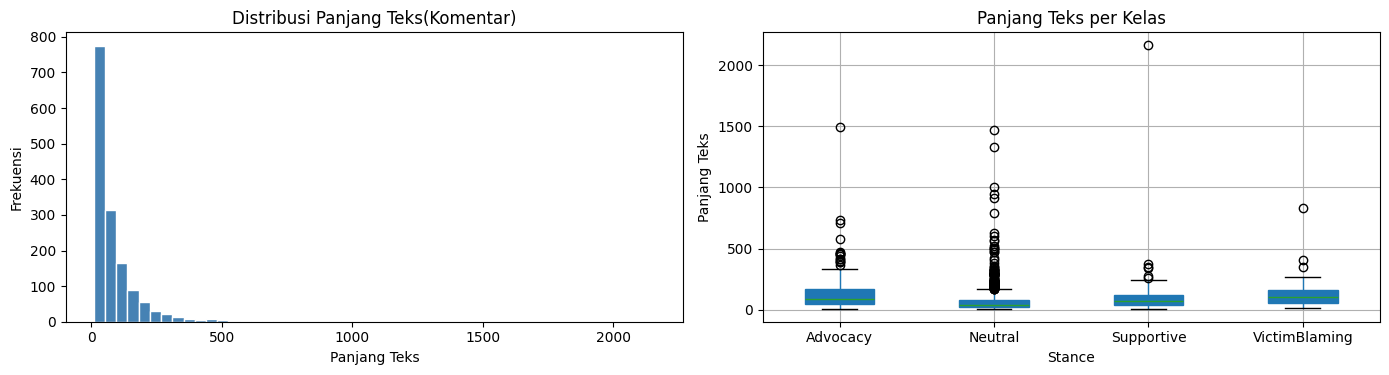

count    1500.000000
mean       88.553333
std       128.391425
min        10.000000
25%        28.000000
50%        51.000000
75%       103.000000
max      2160.000000
Name: panjangData, dtype: float64


In [8]:
data['panjangData'] = data['text'].apply(len)

fig,axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(data['panjangData'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Panjang Teks(Komentar)', fontsize=12)
axes[0].set_xlabel('Panjang Teks')
axes[0].set_ylabel('Frekuensi')

data.boxplot(column='panjangData',by='stance',ax=axes[1],patch_artist=True)
axes[1].set_title('Panjang Teks per Kelas',fontsize=12)
axes[1].set_xlabel('Stance')
axes[1].set_ylabel('Panjang Teks')
plt.suptitle('')

plt.tight_layout()
plt.show()
print(data['panjangData'].describe())

## 4. DATA CLEANING

In [9]:
slangIndonesia = [
    (r'\bkalo ga\b','kalau tidak'),(r'\bkalo gak\b','kalau tidak'),
    (r'\bgabisa\b','tidak bisa'),(r'\bgatau\b','tidak tahu'),
    (r'\bgtau\b','tidak tahu'),(r'\bgada\b','tidak ada'),
    (r'\bgaada\b','tidak ada'),(r'\bgakuat\b','tidak kuat'),
    (r'\bkaga\b','tidak'),(r'\bngga\b','tidak'),(r'\bnggak\b','tidak'),
    (r'\bnggk\b','tidak'),(r'\bgak\b','tidak'),(r'\bgk\b','tidak'),
    (r'\bga\b','tidak'),(r'\bkgk\b','tidak'),(r'\bnga\b','tidak'),
    (r'\bbngt\b','banget'),(r'\bbngeet\b','banget'),(r'\bbangeett\b','banget'),
    (r'\bbangettt\b','banget'),(r'\bbangett\b','banget'),
    (r'\bbgtt\b','banget'),(r'\bbgt\b','banget'),
    (r'\bampek\b','sampai'),(r'\bsampe\b','sampai'),(r'\bsmpe\b','sampai'),
    (r'\bampe\b','sampai'),(r'\bskrng\b','sekarang'),(r'\bskrg\b','sekarang'),
    (r'\bsudh\b','sudah'),(r'\budah\b','sudah'),(r'\budh\b','sudah'),
    (r'\buda\b','sudah'),(r'\bsdh\b','sudah'),(r'\btrss\b','terus'),
    (r'\btrs\b','terus'),(r'\bdpet\b','dapat'),(r'\bdapet\b','dapat'),
    (r'\bdpt\b','dapat'),(r'\bblum\b','belum'),(r'\bblm\b','belum'),
    (r'\bpakek\b','pakai'),(r'\bpake\b','pakai'),(r'\bpke\b','pakai'),
    (r'\bFakyltas\b','fakultas'),(r'\bkrena\b','karena'),(r'\bkrna\b','karena'),
    (r'\bkarna\b','karena'),(r'\bkrn\b','karena'),(r'\bkayak\b','seperti'),
    (r'\bkaya\b','seperti'),(r'\bkyk\b','seperti'),(r'\bkek\b','seperti'),
    (r'\bkalo\b','kalau'),(r'\bklo\b','kalau'),(r'\bklu\b','kalau'),
    (r'\bkl\b','kalau'),(r'\btapii\b','tapi'),(r'\btpi\b','tapi'),
    (r'\btp\b','tapi'),(r'\bjugaa\b','juga'),(r'\bjga\b','juga'),
    (r'\bjg\b','juga'),(r'\byng\b','yang'),(r'\byg\b','yang'),
    (r'\bdgn\b','dengan'),(r'\bdrpd\b','daripada'),(r'\bdr\b','dari'),
    (r'\bmsih\b','masih'),(r'\bmsh\b','masih'),(r'\bmnurut\b','menurut'),
    (r'\bmnrt\b','menurut'),(r'\bmrk\b','mereka'),(r'\bbnyk\b','banyak'),
    (r'\bbyk\b','banyak'),(r'\bgmna\b','bagaimana'),(r'\bgimana\b','bagaimana'),
    (r'\bgmn\b','bagaimana'),(r'\bknapa\b','kenapa'),(r'\bknp\b','kenapa'),
    (r'\bpdhal\b','padahal'),(r'\bpdhl\b','padahal'),(r'\bspt\b','seperti'),
    (r'\bsm\b','sama'),(r'\baj\b','saja'),(r'\byuk\b','ayo'),
    (r'\bantemono\b','pukul'),(r'\bsj\b','saja'),(r'\bmna\b','mana'),
    (r'\bmn\b','mana'),(r'\bmnghukum\b','menghukum'),(r'\bkluarin\b','keluarkan'),
    (r'\bbkn\b','bukan'),(r'\bank\b','anak'),(r'\bemane\b','sayang'),
    (r'\bthx\b','terima kasih'),(r'\butk\b','untuk'),(r'\btruz\b','terus'),
    (r'\bfhui\b','fakultas hukum universitas indonesia'),
    (r'\bfh ui\b','fakultas hukum universitas indonesia'),
    (r'\bfh\b','fakultas hukum'),(r'\bui\b','universitas indonesia'),
    (r'\bks\b','kekerasan seksual'),(r'\bdo\b','drop out'),
    (r'\bppks\b','satgas kekerasan seksual'),(r'\bptn\b','perguruan tinggi negeri'),
    (r'\bpubspeak\b','public speaking'),
    (r'\bplisss\b',''),(r'\bpliss\b',''),(r'\bplis\b',''),(r'\bpls\b',''),
    (r'\banjirr\b',''),(r'\banjir\b',''),(r'\bnjirr\b',''),(r'\bnjir\b',''),
    (r'\banjg\b',''),(r'\banj\b',''),(r'\bjirr\b',''),(r'\bjir\b',''),
    (r'\bwkwkwkwk\b',''),(r'\bwkwkwk\b',''),(r'\bwkwk\b',''),
    (r'\bhahahaha\b',''),(r'\bhahaha\b',''),(r'\bhaha\b',''),
    (r'\bhehe\b',''),(r'\bhihi\b',''),(r'\blmao\b',''),(r'\blol\b',''),
    (r'\bwtf\b',''),(r'\bomg\b',''),(r'\bwth\b',''),
    (r'\bcok\b',''),(r'\bcuy\b',''),(r'\bwoy\b',''),(r'\bwoi\b',''),
    (r'\bih\b',''),(r'\bcih\b',''),(r'\bbtw\b',''),(r'\bfyi\b',''),
    (r'\bcmiiw\b',''),(r'\bcmww\b',''),(r'\bokk\b',''),(r'\boke\b',''),
    (r'\bsih\b',''),(r'\bnih\b',''),(r'\bdong\b',''),
    (r'\bdeh\b',''),(r'\bkok\b',''),(r'\bkan\b',''),
    (r'\blah\b',''),(r'\byah\b',''),(r'\byaa\b',''),
    (r'\bnah\b',''),(r'\beh\b',''),(r'\bahh\b',''),
    (r'\buhh\b',''),(r'\bah\b',''),
]

factory  = StopWordRemoverFactory()
sastrawi = set(factory.get_stop_words())

kataDomain = {
    'korban','pelaku','pelecehan','kekerasan','seksual',
    'perempuan','wanita','cewe','cewek',
    'hukum','kampus','universitas','dosen','mahasiswa','mahasiswi',
    'keadilan','trauma','consent','verbal',
    'grup','chat','speak','drop','out',
    'moral','adab','etika',
    'tidak','bukan','belum','jangan','tanpa',
    'sedih','marah','kecewa','malu','miris','sakit','hancur',
    'berani','salut','bangga','keren','hebat','solid',
    'semangat','dukung','bela','lindungi','aman',
    'proses','sanksi','hukuman','sidang','investigasi',
    'kasus','inside','joke','jokes','template','objektifikasi',
    'normalisasi','penegak',
    'tidak','bisa','mau','tahu','ada',
}

kataTambahan = {
    'kak','bang','nih','sih','dong','deh','aja',
    'udah','ga','gak','nggak','aku','gue','gua','gw',
    'lu','lo','elu','elo','kamu','dia','mereka','kita','kami',
    'itu','ini','jadi','kan','lah','kok',
    'ya','yaa','yah','eh','ah','oh',
    'sticker','fyp','tiktok','like','follow','share',
}

stopWords = (sastrawi.union(kataTambahan)) - kataDomain

def normalisasiSlang(text):
    for x, y in slangIndonesia:
        text = re.sub(x, y, text, flags=re.IGNORECASE)
    return text

def cleanText(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = normalisasiSlang(text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def hapusStopWords(text):
    words    = text.split()
    filtered = [w for w in words if w.lower() not in stopWords or w.lower() in kataDomain]
    return ' '.join(filtered)

def final(text):
    clean = cleanText(text)
    rmv   = hapusStopWords(clean)
    return ' '.join([w for w in rmv.split() if len(w) > 1])

In [10]:
data['CleanText'] = data['text'].apply(final)
data = data[data['CleanText'].str.strip() != ''].reset_index(drop=True)

data.head()

,text,stance,panjangData,CleanText
0,udh bener di UGM aja lah,Neutral,24,bener ugm
1,jurusan hukum ❎\npraktek hukum ✅,Neutral,31,jurusan hukum praktek hukum
2,"Ini masalah rusaknya moral, bukan hal yang sep...",Advocacy,179,rusaknya moral bukan sepele emoji tertawa diku...
3,DO aja semuanya,Advocacy,15,drop out
4,Usut tuntas proses hukum dan pecat mahasiswa b...,Advocacy,50,usut tuntas proses hukum pecat mahasiswa bejat


## 5. ENCODING LABELS

In [11]:
label = {
    'Supportive' : 0,
    'VictimBlaming' : 1,
    'Neutral': 2,
    'Advocacy': 3

}
label_names = ['Supportive', 'VictimBlaming', 'Neutral', 'Advocacy']
data['label'] = data['stance'].map(label)
data['label'].value_counts()

,count
label,
2,1098
3,210
0,129
1,53


## 6. TRAIN AND VALIDATION

In [12]:
X = data['CleanText'].values
y = data['label'].values

TrainX, ValX, TrainY, ValY = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

len(TrainX), len(ValX)

(1192, 298)

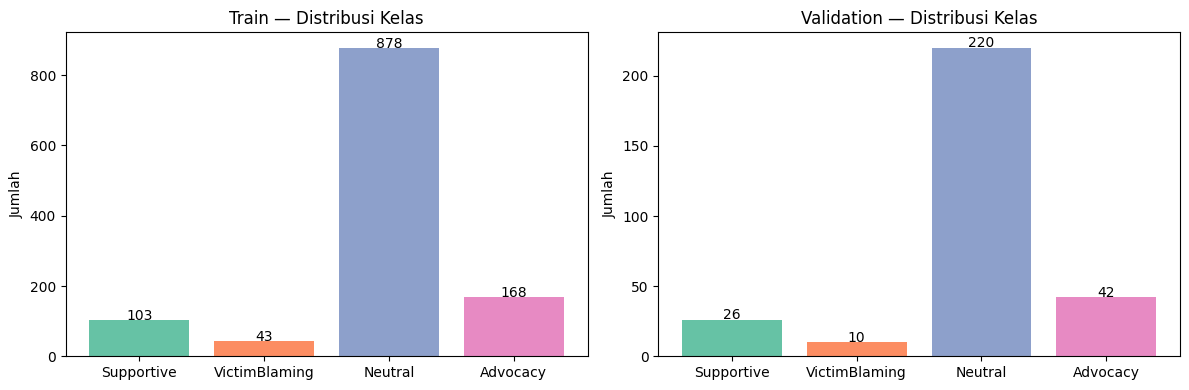

In [13]:
namaLabel = {
    0: 'Supportive',
    1: 'VictimBlaming',
    2: 'Neutral',
    3: 'Advocacy'
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
jumlahTrain = pd.Series(TrainY).value_counts().sort_index()

axes[0].bar(
    [namaLabel[i] for i in jumlahTrain.index],
    jumlahTrain.values,
    color=sns.color_palette('Set2', 4)
)

axes[0].set_title('Train — Distribusi Kelas')
axes[0].set_ylabel('Jumlah')

for indeks, nilai in enumerate(jumlahTrain.values):
    axes[0].text(indeks, nilai + 0.5, str(nilai), ha='center')

jumlahValidasi = pd.Series(ValY).value_counts().sort_index()

axes[1].bar(
    [namaLabel[i] for i in jumlahValidasi.index],
    jumlahValidasi.values,
    color=sns.color_palette('Set2', 4)
)

axes[1].set_title('Validation — Distribusi Kelas')
axes[1].set_ylabel('Jumlah')

for indeks, nilai in enumerate(jumlahValidasi.values):
    axes[1].text(indeks, nilai + 0.5, str(nilai), ha='center')

plt.tight_layout()
plt.show()

## 7. FEATURE ENGINEERING

### 7a. TF-IDF

In [14]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
train_tfidf = tfidf.fit_transform(TrainX)
val_tfidf   = tfidf.transform(ValX)

print(f'TF-IDF train shape: {train_tfidf.shape}')
print(f'TF-IDF val   shape: {val_tfidf.shape}')

TF-IDF train shape: (1192, 5000)
TF-IDF val   shape: (298, 5000)


### 7b. Lexicon Features


In [15]:
emotion_lexicon = {
    'marah': ['marah','bejat','biadab','hancur','benci','emosi',
              'kecewa','dendam','jengkel','tega'],
    'sedih': ['sedih','miris','kasihan','trauma','menangis','duka',
              'prihatin','nyesek','sakit hati','nyelekit'],
    'takut': ['takut','ngeri','ancam','waspada','khawatir','hati hati'],
}

victim_blaming_lexicon = [
    'pakaian','baju','ketat','salahnya','godain',
    'malam','sendirian','terbuka','provokatif','rok',
    'goda','rayuan','salah sendiri','minta','wajar'
]

def extract_emotion_features(texts):
    features = []
    for text in texts:
        text_lower = str(text).lower()
        row = [sum(1 for w in words if w in text_lower)
               for words in emotion_lexicon.values()]
        features.append(row)
    return np.array(features, dtype=float)

def extract_vb_features(texts):
    features = []
    for text in texts:
        text_lower = str(text).lower()
        count = sum(1 for w in victim_blaming_lexicon if w in text_lower)
        features.append([count])
    return np.array(features, dtype=float)

train_emotion_feat = extract_emotion_features(TrainX)
val_emotion_feat   = extract_emotion_features(ValX)

train_vb_feat = extract_vb_features(TrainX)
val_vb_feat   = extract_vb_features(ValX)

print('Emotion feature shape (train):', train_emotion_feat.shape)
print('VB feature shape (train):     ', train_vb_feat.shape)

vb_df = pd.DataFrame({'label': TrainY, 'vb_score': train_vb_feat.flatten()})
print('\nMean VB score per class (train):')
print(vb_df.groupby('label')['vb_score'].mean().rename(index=dict(enumerate(label_names))))

Emotion feature shape (train): (1192, 3)
VB feature shape (train):      (1192, 1)

Mean VB score per class (train):
label
Supportive       0.009709
VictimBlaming    0.186047
Neutral          0.017084
Advocacy         0.047619
Name: vb_score, dtype: float64


## 8. MODELLING

### Evaluasi Helper

In [21]:
def evaluate_model(y_true, y_pred, model_name):
    acc     = accuracy_score(y_true, y_pred)
    b_acc   = balanced_accuracy_score(y_true, y_pred)
    f1_mac  = f1_score(y_true, y_pred, average='macro')
    f1_wt   = f1_score(y_true, y_pred, average='weighted')
    kappa   = cohen_kappa_score(y_true, y_pred)

    print(f'Hasil Eval: {model_name}')
    print(f'Accuracy: {acc:.4f}')
    print(f'Balanced Accuracy: {b_acc:.4f}(lebih adil untuk data imbalanced)')
    print(f'F1 Macro: {f1_mac:.4f}')
    print(f'F1 Weighted: {f1_wt:.4f}')
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(classification_report(y_true, y_pred,target_names=label_names, digits=4))

    cm  = confusion_matrix(y_true, y_pred, labels=[0,1,2,3])
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=11)
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'acc': acc, 'b_acc': b_acc,
            'f1_macro': f1_mac, 'f1_weighted': f1_wt, 'kappa': kappa}

all_results = []

### Model 1 — ComplementNB + TF-IDF


Hasil Eval: ComplementNB + TF-IDF
Accuracy: 0.7047
Balanced Accuracy: 0.4278(lebih adil untuk data imbalanced)
F1 Macro: 0.4305
F1 Weighted: 0.7021
Cohen's Kappa: 0.3072
               precision    recall  f1-score   support

   Supportive     0.2500    0.2692    0.2593        26
VictimBlaming     0.3333    0.1000    0.1538        10
      Neutral     0.8219    0.8182    0.8200       220
     Advocacy     0.4583    0.5238    0.4889        42

     accuracy                         0.7047       298
    macro avg     0.4659    0.4278    0.4305       298
 weighted avg     0.7044    0.7047    0.7021       298



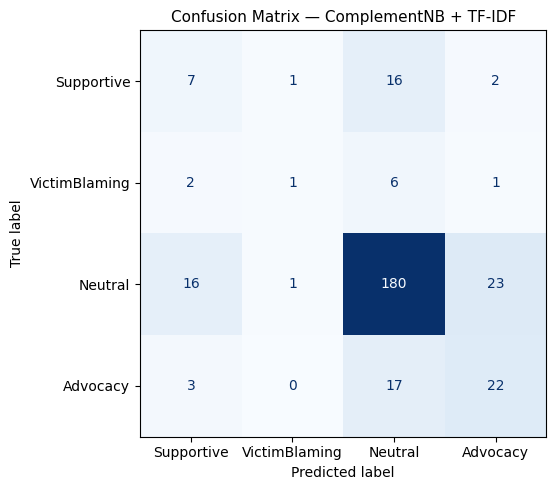

In [22]:
nb_model = ComplementNB()
nb_model.fit(train_tfidf, TrainY)
pred_nb = nb_model.predict(val_tfidf)

r1 = evaluate_model(ValY, pred_nb, 'ComplementNB + TF-IDF')
all_results.append(r1)

### Model 2 — SVM + TF-IDF (Baseline)


Tuning SVM baseline (TF-IDF)
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best C (SVM baseline): {'C': 1}
Hasil Eval: SVM + TF-IDF (Baseline)
Accuracy: 0.7114
Balanced Accuracy: 0.4892(lebih adil untuk data imbalanced)
F1 Macro: 0.4753
F1 Weighted: 0.7137
Cohen's Kappa: 0.3637
               precision    recall  f1-score   support

   Supportive     0.4545    0.3846    0.4167        26
VictimBlaming     0.2500    0.1000    0.1429        10
      Neutral     0.8390    0.7818    0.8094       220
     Advocacy     0.4328    0.6905    0.5321        42

     accuracy                         0.7114       298
    macro avg     0.4941    0.4892    0.4753       298
 weighted avg     0.7285    0.7114    0.7137       298



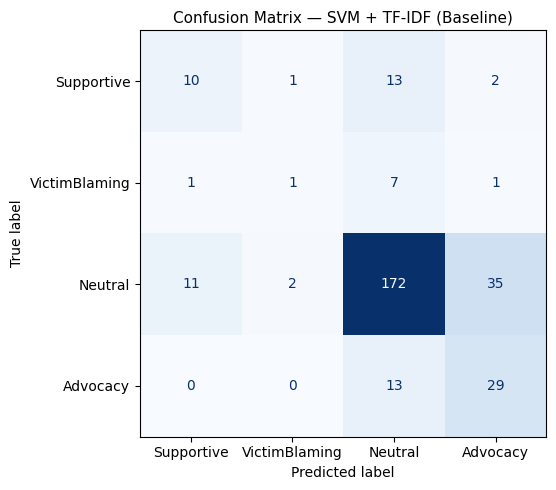

In [23]:
print('Tuning SVM baseline (TF-IDF)')
svm_base_cv = GridSearchCV(
    SVC(kernel='linear', class_weight='balanced'),
    param_grid={'C': [0.01, 0.1, 1, 10]},
    cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
)
svm_base_cv.fit(train_tfidf, TrainY)
print('Best C (SVM baseline):', svm_base_cv.best_params_)

svm_base = svm_base_cv.best_estimator_
pred_svm_base = svm_base.predict(val_tfidf)

r2 = evaluate_model(ValY, pred_svm_base, 'SVM + TF-IDF (Baseline)')
all_results.append(r2)

### Model 3 — SVM + TF-IDF + Emotion Features

Tuning SVM + Emotion features
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best C (SVM + Emotion): {'C': 1}
Hasil Eval: SVM + TF-IDF + Emotion Feat
Accuracy: 0.7315
Balanced Accuracy: 0.5093(lebih adil untuk data imbalanced)
F1 Macro: 0.4964
F1 Weighted: 0.7317
Cohen's Kappa: 0.4004
               precision    recall  f1-score   support

   Supportive     0.4783    0.4231    0.4490        26
VictimBlaming     0.2500    0.1000    0.1429        10
      Neutral     0.8462    0.8000    0.8224       220
     Advocacy     0.4762    0.7143    0.5714        42

     accuracy                         0.7315       298
    macro avg     0.5127    0.5093    0.4964       298
 weighted avg     0.7419    0.7315    0.7317       298



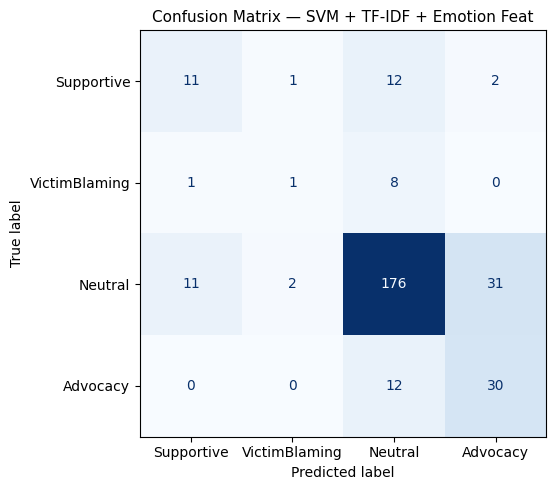

In [24]:
X_train_emo = hstack([train_tfidf, train_emotion_feat])
X_val_emo   = hstack([val_tfidf,   val_emotion_feat])

print('Tuning SVM + Emotion features')
svm_emo_cv = GridSearchCV(
    SVC(kernel='linear', class_weight='balanced'),
    param_grid={'C': [0.01, 0.1, 1, 10]},
    cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
)
svm_emo_cv.fit(X_train_emo, TrainY)
print('Best C (SVM + Emotion):', svm_emo_cv.best_params_)

svm_emotion = svm_emo_cv.best_estimator_
pred_svm_emo = svm_emotion.predict(X_val_emo)

r3 = evaluate_model(ValY, pred_svm_emo, 'SVM + TF-IDF + Emotion Feat')
all_results.append(r3)

### Model 4 — SVM + TF-IDF + VictimBlaming Features

Tuning SVM + VictimBlaming features
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best C (SVM + VB): {'C': 1}
Hasil Eval: SVM + TF-IDF + VB Feat
Accuracy: 0.7148
Balanced Accuracy: 0.5381(lebih adil untuk data imbalanced)
F1 Macro: 0.5212
F1 Weighted: 0.7216
Cohen's Kappa: 0.3818
               precision    recall  f1-score   support

   Supportive     0.4545    0.3846    0.4167        26
VictimBlaming     0.3333    0.3000    0.3158        10
      Neutral     0.8465    0.7773    0.8104       220
     Advocacy     0.4462    0.6905    0.5421        42

     accuracy                         0.7148       298
    macro avg     0.5201    0.5381    0.5212       298
 weighted avg     0.7387    0.7148    0.7216       298



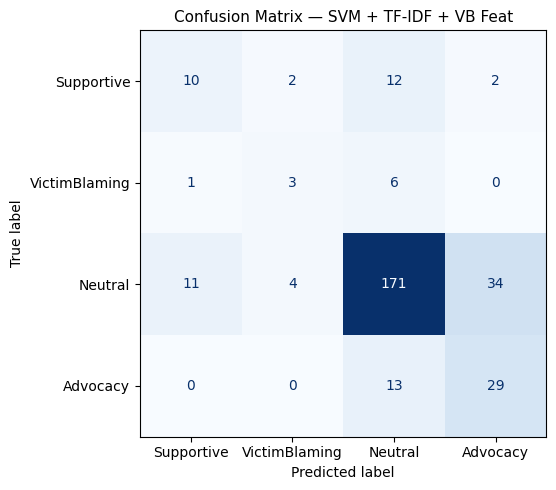

In [25]:
X_train_vb = hstack([train_tfidf, train_vb_feat])
X_val_vb   = hstack([val_tfidf,   val_vb_feat])

print('Tuning SVM + VictimBlaming features')
svm_vb_cv = GridSearchCV(
    SVC(kernel='linear', class_weight='balanced'),
    param_grid={'C': [0.01, 0.1, 1, 10]},
    cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
)
svm_vb_cv.fit(X_train_vb, TrainY)
print('Best C (SVM + VB):', svm_vb_cv.best_params_)

svm_vb = svm_vb_cv.best_estimator_
pred_svm_vb = svm_vb.predict(X_val_vb)

r4 = evaluate_model(ValY, pred_svm_vb, 'SVM + TF-IDF + VB Feat')
all_results.append(r4)

## 9. MODEL COMPARISON

                                acc   b_acc  f1_macro  f1_weighted   kappa
model                                                                     
ComplementNB + TF-IDF        0.7047  0.4278    0.4305       0.7021  0.3072
SVM + TF-IDF (Baseline)      0.7114  0.4892    0.4753       0.7137  0.3637
SVM + TF-IDF + Emotion Feat  0.7315  0.5093    0.4964       0.7317  0.4004
SVM + TF-IDF + VB Feat       0.7148  0.5381    0.5212       0.7216  0.3818


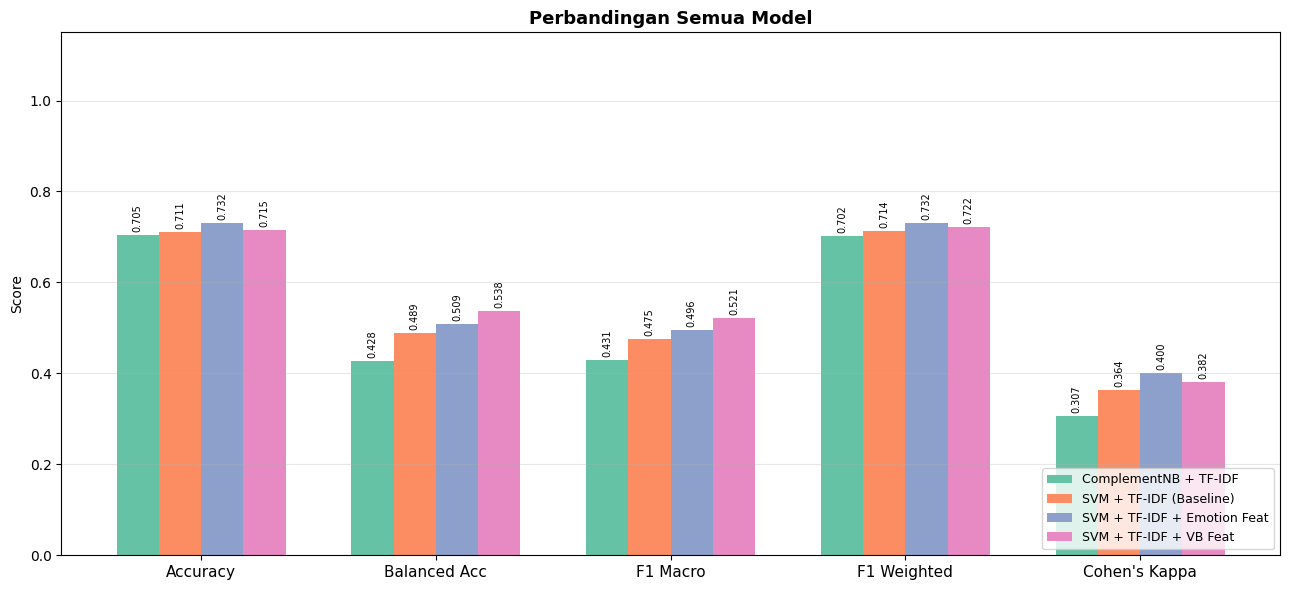


Best model (Macro F1): SVM + TF-IDF + VB Feat — 0.5212


In [26]:
df_results = pd.DataFrame(all_results).set_index('model')
print(df_results.round(4).to_string())

metrics = ['acc','b_acc','f1_macro','f1_weighted','kappa']
metric_labels = ['Accuracy','Balanced Acc','F1 Macro','F1 Weighted',"Cohen's Kappa"]

x= np.arange(len(metrics))
width = 0.18
palette = sns.color_palette('Set2', len(df_results))
fig, ax = plt.subplots(figsize=(13, 6))
for i, (model_name, row) in enumerate(df_results.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width=width,
                  label=model_name, color=palette[i])
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2, rotation=90)

ax.set_xticks(x + width * (len(df_results) - 1) / 2)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Semua Model', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best = df_results['f1_macro'].idxmax()
print(f'\nBest model (Macro F1): {best} — {df_results.loc[best, "f1_macro"]:.4f}')